In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.ticker as ticker
import pickle

n_bins=10
hours_per_timestep=60/5
previous_hours=11
previous_times=-hours_per_timestep*previous_hours

In [2]:
dir = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc', decode_timedelta=True) #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc', decode_timedelta=True) #***
# res='1km';t_res='5min'
# Np_str='1e6'

# dx = 1km; Np = 50M; Nz = 95
#Importing Model Data
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc', decode_timedelta=True) #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc', decode_timedelta=True) #***
res='1km'; t_res='1min_95nz'; Np_str='50e6'

# # dx = 250m; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m_1min_50M.nc', decode_timedelta=True) #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m_1min_50M.nc', decode_timedelta=True) #***
# res='250m'; t_res='1min'; Np_str='50e6'

In [3]:
# Define land and ocean slices
fraction=2/8
land = slice(int(len(data['xh'])*fraction), int(len(data['xh'])))
ocean = slice(0, int(len(data['xh'])*fraction))

In [4]:
def GetData1(var_name):
    land_data = data[var_name].isel(xh=land).data#.mean(dim=['xh', 'yh'])
    ocean_data = data[var_name].isel(xh=ocean).data#.mean(dim=['xh', 'yh'])
    
    land_data_mean = np.mean(land_data,axis=(1,2))
    ocean_data_mean = np.mean(ocean_data,axis=(1,2))
    
    return land_data_mean,ocean_data_mean

def GetData2(var_name):
    land_data = data[var_name].isel(xh=land,zh=0).data#.mean(dim=['xh', 'yh'])
    ocean_data = data[var_name].isel(xh=ocean,zh=0).data#.mean(dim=['xh', 'yh'])
    
    land_data_mean = np.mean(land_data,axis=(1,2))
    ocean_data_mean = np.mean(ocean_data,axis=(1,2))
    
    return land_data_mean,ocean_data_mean

def SaveLandOceanData(data_list, filename=dir+'Figures/campaign_data/'+f'land_ocean_data_{res}_{t_res}.pkl'):
    with open(filename, 'wb') as f:
        pickle.dump(data_list, f)
    print(f"Saved land and ocean data to '{filename}'")

def LoadLandOceanData(filename=dir+'Figures/campaign_data/'+f'land_ocean_data_{res}_{t_res}.pkl'):
    with open(filename, 'rb') as f:
        data_list = pickle.load(f)
    return data_list[0], data_list[1]

Saved land and ocean data to '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Figures/campaign_data/land_ocean_data_1km_1min_95nz.pkl'


(-132.0, 693.0)

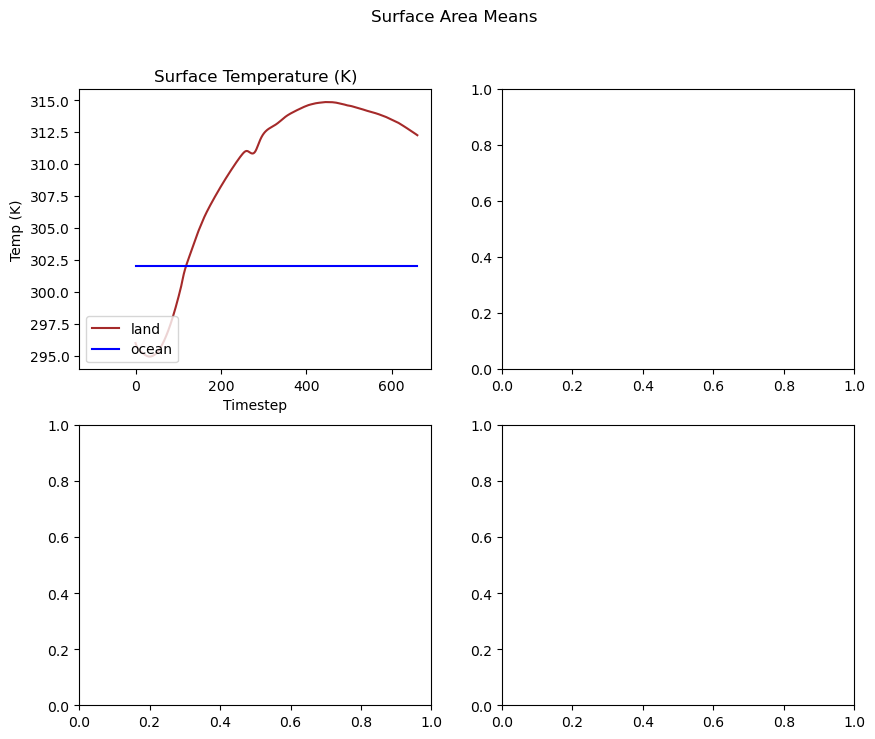

In [5]:
# Create figure and axes
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Surface Area Means')

# Surface Temperature Plot
ax = axes[0, 0]
var_name='tsk'
[land_data_mean,ocean_data_mean] = GetData1(var_name)
SaveLandOceanData([land_data_mean,ocean_data_mean], filename=dir+'Figures/campaign_data/'+f'land_ocean_data_{res}_{t_res}.pkl')
ax.plot(land_data_mean, color='brown', label='land')
ax.plot(ocean_data_mean, color='blue', label='ocean')
ax.set_title('Surface Temperature (K)')
ax.set_xlabel('Timestep')
ax.set_ylabel('Temp (K)')
ax.legend(loc='lower left')
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=n_bins))  # Set Y-Ticks
ax.set_xlim(left=previous_times) #matching data diurnal cycle

# # QV Flux Plot
# ax = axes[0, 1]
# var_name='qvflux'
# [land_data_mean,ocean_data_mean] = GetData1(var_name)
# ax.plot(land_data_mean, color='brown', label='land')
# ax.plot(ocean_data_mean, color='blue', label='ocean')
# ax.set_title('QV Flux (K)')
# ax.set_xlabel('Timestep')
# ax.set_ylabel(r'qvflux ($g\ g^{-1} m\ s^{-1}$)')
# ax.legend(loc='lower left')
# ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=n_bins))  # Set Y-Ticks
# ax.set_xlim(left=previous_times) #matching data diurnal cycle

# # Theta Flux Plot
# ax = axes[1, 0]
# var_name='thflux'
# [land_data_mean,ocean_data_mean] = GetData1(var_name)
# ax.plot(land_data_mean, color='brown', label='land')
# ax.plot(ocean_data_mean, color='blue', label='ocean')
# ax.set_title('Theta Flux (K)')
# ax.set_xlabel('Timestep')
# ax.set_ylabel(r'thflux ($K\ m\ s^{-1}$)')
# ax.legend(loc='lower left')
# ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=n_bins))  # Set Y-Ticks
# ax.set_xlim(left=previous_times) #matching data diurnal cycle

# # U Wind Component Plot
# ax = axes[1, 1]
# var_name='uinterp'
# [land_data_mean,ocean_data_mean] = GetData2(var_name)
# ax.plot(land_data_mean, color='brown', label='land')
# ax.plot(ocean_data_mean, color='blue', label='ocean')
# ax.set_title(r'U ($m\ s^{-1}$)')
# ax.set_xlabel('Timestep')
# ax.set_ylabel(r'u ($m\ s^{-1}$)')
# ax.legend(loc='lower left')
# ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=n_bins))  # Set Y-Ticks
# ax.set_xlim(left=previous_times) #matching data diurnal cycle